In [2]:
from ezphot.utils import DataBrowser
from ezphot.utils import SDTDataQuerier

# 📸 Image Stacking with EZPhot

This notebook demonstrates how to perform image stacking using the EZPhot package. Image stacking is a fundamental technique in astronomical image processing that combines multiple exposures to improve signal-to-noise ratio and reduce noise.

## 🎯 What You'll Learn

- How to sync and query astronomical data from databases
- How to load and inspect science images
- How to estimate and subtract background from images
- Best practices for memory management when working with large datasets

## 🔄 Image Stacking Workflow

```mermaid
graph TD
    A[📊 Database/Data Source] --> B[🔄 Sync Data]
    B --> C[🔍 Query & Filter Images]
    C --> D[📷 Load Science Images]
    D --> E[👁️ Inspect Images]
    E --> F[🌌 Background Estimation]
    F --> G[➖ Background Subtraction]
    G --> H[📈 Image Stacking]
    H --> I[✨ Final Stacked Image]
    
    style A fill:#e1f5fe
    style I fill:#c8e6c9
    style F fill:#fff3e0
    style G fill:#fff3e0
```

## 📚 Table of Contents

1. **[Load Data](#1-load-data)** - Sync and query astronomical data
2. **[Check Images](#2-check-your-image)** - Inspect and visualize loaded images  
3. **[Background Estimation](#2-background-estimation)** - Calculate and subtract background
4. **[Image Stacking](#3-image-stacking)** - Combine multiple exposures (coming soon)


## 1. 📊 Load Data

In this section, we'll learn how to:
- Connect to the SDT database and sync astronomical data
- Use the `DataBrowser` class to query and filter images
- Load science images for processing

> **💡 Tip**: The `SDTDataQuerier` class provides methods to sync data from a central database to your local workspace, making it easy to work with large astronomical datasets.

### 🔧 Initialize SDT Data Querier

First, let's create an instance of the `SDTDataQuerier` class and explore its available methods. This class provides tools to sync and query astronomical data from the SDT database.


In [3]:
# If you connected the database, you can easily sync the data from the database. 
sdtquery = SDTDataQuerier()
sdtquery.help()

Help for SDTDataQuerier


Public methods:
- show_obsdestdata(foldername: str, show_only_numbers: bool = False, pattern: str = '*.fits')
- show_obsdestfolder(folder_key: str = '*')
- show_obssourcedata(foldername: str, show_only_numbers: bool = False, pattern: str = '*.fits')
- show_obssourcefolder(folder_key: str = '*')
- show_scidestdata(targetname: str, show_only_numbers: bool = False, key: str = 'filter', pattern: str = '*.fits')
- show_scisourcedata(targetname: str, show_only_numbers: bool = False, key: str = 'filter', file_pattern: str = '*.fits')
- show_scisourcefolder(folder_key: str = '*')
- sync_obsdata(foldername: str, file_pattern: str = '*.fits', ignore_exists: bool = True)
- sync_scidata(targetname: str, file_pattern: str = '*.fits', ignore_exists: bool = True)


### 📥 Sync Data from Database

Now we'll sync data for our target object `T00528` from the source directory to our local destination directory. This process uses `rsync` to efficiently copy only the files we need.


**📋 Available Methods**: The SDTDataQuerier provides methods for:
- `sync_scidata()`: Sync science data from source to destination
- `show_scisourcedata()`: Display available source data
- `show_scidestdata()`: Display synced destination data


In [4]:
# sync_scidata method will run multiple rsync between Science Source directory and destination directory.
print('Source directory:', sdtquery.helper.config['SDTDATA_SCISOURCEDIR'])
print('Target directory:', sdtquery.helper.config['SDTDATA_SCIDESTDIR'])
target_name = 'T00528'
sdtquery.sync_scidata(
    targetname = target_name,
    file_pattern = '*.fits',
    ignore_exists = True
)

Source directory: /home/hhchoi1022/ezphot/data/connecteddata/7DT/processed_1x1_gain2750
Target directory: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1
Running:Running:Running:Running:Running:Running:Running:Running:Running:Running:Running:Running:      rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *.fits --exclude * /home/hhchoi1022/ezphot/data/connecteddata/7DT/processed_1x1_gain2750/T00528/7DT06/ /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT06/      rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *.fits --exclude * /home/hhchoi1022/ezphot/data/connecteddata/7DT/processed_1x1_gain2750/T00528/7DT10/ /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT10/
rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *.fits --exclude * /home/hhchoi1022/ezphot/data/connect

**🔄 Sync Progress**: The rsync process copies FITS files from the source directory to your local destination directory. The `--ignore-existing` flag ensures we don't re-download files that already exist locally.


### 🔍 Query Data with DataBrowser

The `DataBrowser` class allows us to query and filter our synced data. Here we'll explore the available keys and their values to understand what data we have access to.


**🗂️ Data Structure**: The DataBrowser organizes data by:
- **Observatory**: 7DT (Seven-Degree Telescope)
- **Telescope Keys**: Various telescope configurations
- **Object Names**: Target objects (T00528, T23977, etc.)
- **Telescope Names**: Individual telescopes (7DT01-7DT16)
- **Filters**: Available photometric filters (g, r, i, z, and medium-band filters)


In [5]:
# Then, you can query your data with DataBrowser class. 
# Since the data is copied to your private directory (['SCIDATA_SCIDESTDIR'](e.g. ~/ezphot/data/scidata by default) in configuration), you can use it as your own data. 
# You can also use it as a context for ezphot. 

dbrowser = DataBrowser('scidata')
# You can query the data with the below keys.
for key, value in dbrowser.keys.items():
    print(key, value)


observatory {'7DT'}
telkey {'7DT_C361K_HIGH_1x1'}
objname {'T23977', 'T03198', 'T13557', 'T13825', 'T09041', 'T23968', 'T02874', 'T20716', 'T03051', 'T03580', 'T03263', 'T12165', 'T22614', 'T01501', 'T06914', 'T13558', 'T05107', 'T03704', 'T02595', 'T22924', 'T21343', 'T23736', 'T13257', 'T02535', 'T06269', 'T11764', 'T25043', 'T14918', 'T00405', 'T11148', 'T10627', 'T16724', 'T00486', 'T10452', 'T00529', 'T11573', 'T21610', 'T13496', 'T13707', 'T13722', 'T13559', 'T00464', 'T11882', 'T15696', 'T16683', 'T00463', 'T21742', 'T00465', 'T01580', 'T13560', 'T11971', 'T10413', 'T07128', 'T08679', 'T08643', 'T07169', 'T02072', 'T15434', 'T25223', 'T00577', 'T23142', 'T21733', 'T01505', 'T11622', 'T00527', 'T24028', 'T03898', 'T24804', 'T03377', 'T12732', 'T19684', 'T05004', 'T08297', 'T13520', 'T03768', 'T13824', 'T09543', 'T10228', 'T12053', 'T09373', 'T23488', 'T04803', 'T03364', 'T17321', 'T13823', 'T21330', 'T01314', 'T11109', 'T00409', 'T05634', 'T06467', 'T14712', 'T14574', 'T03458', '

**✅ Search Results**: Found 66 FITS files matching our criteria. These are the images we'll use for stacking.


### 🎯 Filter and Search Images

Let's filter our data to find specific images. We'll search for:
- **Target**: T00528
- **Telescope**: 7DT16  
- **Filter**: r-band
- **Pattern**: Files ending with `*100.fits`


**📊 Loading Progress**: 
- Successfully loaded 66 ScienceImage objects
- Created metadata table with image properties
- All images are now ready for processing


In [6]:
dbrowser.objname = target_name
dbrowser.telname = '7DT16'
dbrowser.filter = 'r'
dbrowser.search('*100.fits', return_type = 'path')

[INFO] Found 66 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'


['/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074905_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001416_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074535_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250820_032116_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_000705_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_001035_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001601_r_100.fits',


### 📷 Load Science Images

Now we'll load the filtered images as `ScienceImage` objects and create a metadata table. This gives us access to both the image data and their properties.


In [7]:
# If you wish to get the ScienceImage object, 
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
target_imglist = target_imgset.target_images
# If you wish to get the metadata table from the keys, 
metadata_table = dbrowser.search('*100.fits', return_type = 'imginfo')

[INFO] Found 66 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'


Loading Science Images: 100%|██████████| 66/66 [00:00<00:00, 71.52it/s]


[INFO] Found 66 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'
Loaded 66 FITS files from /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r
Total FITS files combined: 66


### 📊 View Metadata Table

Let's examine the metadata table to understand the properties of our loaded images.


In [9]:
metadata_table

file,altitude,azimuth,ccd-temp,gain,filter,imgtype,exptime,obsdate,locdate,jd,mjd,binning,object,objctid,obsmode,specmode,note,telescop
str120,str32,str32,str32,str21,str1,str5,str32,str23,str23,str32,str32,str21,str6,str32,str4,str7,str9,str5
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits,37.80566,167.202362,-10.0,2750,r,LIGHT,100.0,2025-09-05T00:04:08.000,2025-09-04 20:04:08.000,2460923.50287037,60923.00287037037,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074905_r_100.fits,35.847003,193.97872,-10.2,2750,r,LIGHT,100.0,2025-09-02T07:49:05.000,2025-09-02 03:49:05.000,2460920.8257523146,60920.32575231481,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001416_r_100.fits,37.536132,167.00423,-10.1,2750,r,LIGHT,100.0,2025-09-01T00:14:16.000,2025-08-31 20:14:16.000,2460919.509907407,60919.00990740741,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074535_r_100.fits,36.029225,193.892131,-9.9,2750,r,LIGHT,100.0,2025-09-02T07:45:35.000,2025-09-02 03:45:35.000,2460920.8233217592,60920.32332175926,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250820_032116_r_100.fits,42.588008,174.57094,-10.1,2750,r,LIGHT,100.0,2025-08-20T03:21:16.000,2025-08-19 23:21:16.000,2460907.6397685185,60907.13976851852,1,T00528,58b4f2a07b0246b7b9d68efb4021c28f,Spec,specall,None,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_000705_r_100.fits,37.758685,167.166926,-9.9,2750,r,LIGHT,100.0,2025-09-04T00:07:05.000,2025-09-03 20:07:05.000,2460922.5049189813,60922.00491898148,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_001035_r_100.fits,37.925522,167.294357,-9.9,2750,r,LIGHT,100.0,2025-09-04T00:10:35.000,2025-09-03 20:10:35.000,2460922.507349537,60922.00734953704,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001601_r_100.fits,37.621042,167.065116,-10.2,2750,r,LIGHT,100.0,2025-09-01T00:16:01.000,2025-08-31 20:16:01.000,2460919.5111226854,60919.01112268519,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_075606_r_100.fits,35.478983,194.141241,-10.0,2750,r,LIGHT,100.0,2025-09-02T07:56:06.000,2025-09-02 03:56:06.000,2460920.830625,60920.330625,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16


### 🖼️ Visualize Image with Coordinates

Let's display the first image with coordinate information to see the field of view and understand what we're working with.


## 2. 👁️ Check Your Images

Now that we have loaded our data, let's inspect the images to understand their properties and quality:

- **Visualize images** using coordinate display
- **Manage memory** efficiently when working with large datasets
- **Use external tools** like DS9 for detailed image inspection

> **⚠️ Memory Warning**: Astronomical images can be large. Always use `ScienceImage.clear()` to free memory when you're done with an image.

### ⚠️ Memory Management Example

**Important**: When you load image data, it's stored in memory. Here's how to manage memory efficiently:


(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'calib_7DT16_T00528_20250905_000408_r_100.fits'}>)

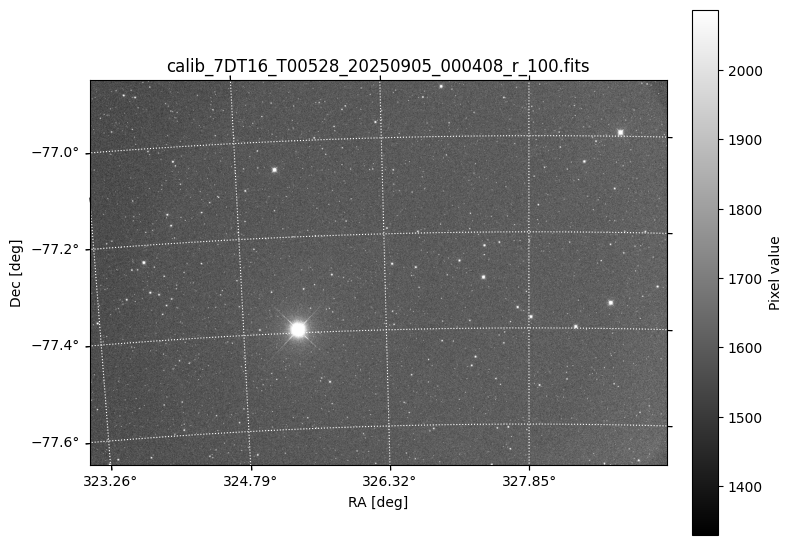

In [10]:
target_imglist[0].show('coord')

### 🧹 Clear Memory

Use `ScienceImage.clear()` to free memory when you're done with an image:


In [13]:
# [CAUTION] For memory management, NOTE the below example.
# When you run any functions that load the data, all data are stored in the memory (data_load = True).
target_img = target_imglist[0]
target_img

ScienceImage(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  imgtype     = LIGHT,
  exptime     = 100.0,
  filter      = r,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r
)

**🛠️ Background Generator Methods**:
- `estimate_with_sep()`: Use SEP algorithm for background estimation
- `estimate_with_photutils()`: Use Photutils for background estimation [Obsolete] 
- `subtract_background()`: Subtract estimated background from images


### 🔭 External Image Viewer (DS9)

You can also view images using DS9 if X11 forwarding is available. This provides advanced image analysis capabilities.


In [15]:
#To clear the memory, run ScienceImage.clear()
target_img = target_imglist[0]
target_img.clear()
target_img

ScienceImage(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  imgtype     = LIGHT,
  exptime     = 100.0,
  filter      = r,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r
)

## 🎉 Summary

In this notebook, we've learned how to:

1. **📊 Load Data**: Sync astronomical data from databases and query with DataBrowser
2. **👁️ Inspect Images**: Visualize and manage science images with proper memory handling
3. **🌌 Estimate Background**: Use SEP algorithm to create accurate background models

## 🚀 Next Steps

The next phase of image stacking would involve:
- **Image Alignment**: Register images to a common coordinate system
- **Quality Assessment**: Evaluate image quality and reject poor exposures
- **Stacking**: Combine aligned images using various algorithms (median, mean, etc.)
- **Final Processing**: Apply final calibrations and create the stacked image

## 📚 Additional Resources

- [EZPhot Documentation](https://ezphot.readthedocs.io/)
- [SEP Documentation](https://sep.readthedocs.io/)
- [Astronomical Image Processing Best Practices](https://astropy.org/)

---

*This notebook demonstrates the EZPhot package's capabilities for astronomical image processing. For questions or contributions, please visit the project repository.*


### 🛠️ Initialize Background Generator

The `BackgroundGenerator` class provides methods to estimate and subtract background from astronomical images. Let's explore its capabilities.


In [16]:
# You can check the image with ds9 if X11 forward is available (via SSH)
target_img.run_ds9()

Running "ds9 -scalemode zscale -scale lock yes -frame lock image /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits &" in the terminal...


bash: cannot set terminal process group (2263633): Inappropriate ioctl for device
bash: no job control in this shell


### 🌌 Estimate Background with SEP

We'll use the SEP (Source Extractor Python) algorithm to estimate the background. This method:
- Uses a 2D background model with 128×128 pixel boxes
- Applies a 3×3 filter to smooth the background
- Automatically handles source masking


## 3. 🌌 Background Estimation

Background estimation is crucial for accurate photometry and image analysis. In this section, we'll:

- **Estimate background** using the SEP (Source Extractor Python) algorithm
- **Visualize background models** to ensure quality
- **Apply source masking** to improve background estimation

> **🔬 Science Note**: Background estimation removes sky brightness and instrumental effects, revealing the true astronomical sources in your images.

### 🎭 Advanced Background Estimation

Sometimes the background model may include real sources like saturated stars or extended objects. In such cases, you can apply source masks to improve the background estimation.

> **💡 Pro Tip**: Source masking helps create cleaner background models by excluding bright objects that could bias the background calculation.


In [20]:
from ezphot.methods import BackgroundGenerator
# You can calculate the background map with the BackgroundGenerator class. 

bg_generator = BackgroundGenerator()
bg_generator.help()

Help for BackgroundGenerator

Public methods:
- estimate_with_photutils(target_img: Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.referenceimage.ReferenceImage], target_mask: Optional[ezphot.imageobjects.mask.Mask] = None, is_2D_bkg: bool = True, box_size: int = 128, filter_size: int = 3, bkg_estimator: str = 'sextractor', save: bool = True, verbose: bool = True, visualize: bool = True, save_fig: bool = False)
- estimate_with_sep(target_img: Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.referenceimage.ReferenceImage], target_srcmask: Optional[ezphot.imageobjects.mask.Mask] = None, target_ivpmask: Optional[ezphot.imageobjects.mask.Mask] = None, is_2D_bkg: bool = True, box_size: int = 32, filter_size: int = 3, save: bool = True, verbose: bool = True, visualize: bool = True, save_fig: bool = False)
- subtract_background(target_img: Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.referenceimage.ReferenceImage], 

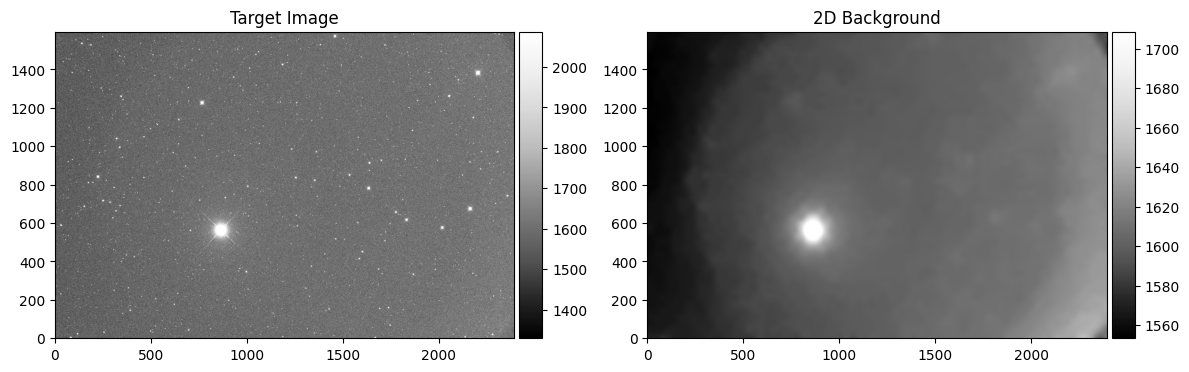

In [22]:
# Calculate the background map with SEP
target_bkg = bg_generator.estimate_with_sep(
    target_img = target_img,
    target_srcmask = None,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 128,
    filter_size = 3,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False
)

You might not satisfied the background model includes real source such as saturated source and extended sources. 
In this case, you can apply source mask to your background model. 
